Немного слов. В предыдущем ноутбуке я забыл рассказать про суть беггинга и бустинга. Ну так вот, фастиком  

Беггинг - ансамблевый метод, в котором мы обучаем несколько моделей на разных, случайных подвыборках данного нам датасета(это называется бутстрапом), а затем берётся среднее предсказание(для регрессии) или мода(самое часто встречающееся предсказание от моделей, для классификации). Тут мы объединяем модели параллельно  

Бустинг - ансамблевый метод, в котором несколько моделей исправляют ошибки друг друга. Тут мы объединяем модели последовательно

Теперь про stacking и voting(нет, я не буду писать эти слова кириллицей)  

Stacking - такой ансамблевый метод, который использует мета-модель для объединения предсказаний моделей первого уровня. Часто как мета-модель используют линейные модели  

Voting - более простой ансамблевый метод чем stacking, который просто берёт самое часто встречающееся(моду) предсказания(hard voting) или считает среднее арифметическое вероятностей для каждого класса и выбирается класс с самой высокой средней вероятностью(soft voting). Плюс в том что не требует мета-модели для объединения предсказаний

Реализуем stacking и погоняем разные модели в нем на каком-нибудь соревновательном датасете

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.model_selection import train_test_split

In [58]:
class Stacking:
    def fit(self, models, meta_model, X, y):
        fitted_models = []
        X = np.asarray(X)
        y = np.asarray(y)
        #Тут крайне важный момент. Если мы будем и мета-модель, и модели первого уровня обучать на одном и том же X, то это будет очень плохо
        #потому что мета-модель будет выдавать слишком оптимистичные предсказания
        #Для этого умные люди придумали разбивать датасет на подвыборки(фолды, не путать с бутстрапом, подвыборки не повторяются!)
        #А мета-модель обучают на предсказаниях всех моделей, такие предсканазия назвали OOF-предсказаниями(out-of-fold)
        #прежде чем касаться stacking, конечно, стоило бы потыкать кросс-валидацию, нуниче, всё будет хорошо
        #Малость по фолдам: тут мы для каждой модели будем выдавать по 1 фолду, то есть k=len(models)
        oof_predictions = np.zeros((len(X), len(models)))#удобнее работать с табличкой нампаевской
        kf = KFold(
            n_splits=len(models),
            shuffle=True,
            random_state=42
        )
        for model_idx, model in enumerate(models):
            for train_idx, val_idx in kf.split(X):
                model_copy = clone(model)
                model_copy.fit(X[train_idx], y[train_idx])
                pred = model_copy.predict(X[val_idx])
                oof_predictions[val_idx, model_idx] = pred
        meta_model.fit(oof_predictions, y)
        for model in models:
            model_copy = clone(model)
            model_copy.fit(X, y)
            fitted_models.append(model_copy)
        return fitted_models, meta_model
            
    def predict(self, fitted_models, meta_model, X):
        X = np.asarray(X)
        predictions = []
        for model in fitted_models:
            pred = model.predict(X)
            predictions.append(pred)
        predictions = np.array(predictions).T
        return meta_model.predict(predictions)

In [33]:
df = pd.read_csv('../datasets/bank.csv', sep=';')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


In [34]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


Не хочется проводить EDA. Пофиг. Просто возьмём 5 модель и проансамблируем


In [35]:
X = pd.get_dummies(
    df.drop(columns=['y']),
    drop_first=True
)
y = np.where(df['y'] == 'yes', 1, 0) 
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC#я знаю что svm ещё не разбирали, но мне плевать

In [52]:
stacking = Stacking()
fitted_models, meta_model = stacking.fit([ 
                                          DecisionTreeClassifier(),
                                          RandomForestClassifier(),
                                          KNeighborsClassifier(),
                                          SVC()
                                            ], 
                                         LogisticRegression(max_iter=1000),
                                         X_train, y_train)


In [53]:
from sklearn.metrics import roc_auc_score


In [54]:
y_pred = stacking.predict(fitted_models, meta_model, X_test)
print(roc_auc_score(y_test, y_pred))

0.5770417495029821


C:\Users\hira0mi\Desktop\job_preparation\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\hira0mi\Desktop\job_preparation\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\hira0mi\Desktop\job_preparation\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\hira0mi\Desktop\job_preparation\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


In [55]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(roc_auc_score(y_test, y_pred))

0.6075506958250497


In [56]:
df_test = pd.read_csv('../datasets/test.csv', sep=',')
df_test.head()

,Id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,1,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown
1,2,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown
2,3,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown
3,4,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown
4,5,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown


In [59]:
X_test = pd.get_dummies(df_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

pred = stacking.predict(fitted_models, meta_model, X_test)

C:\Users\hira0mi\Desktop\job_preparation\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\hira0mi\Desktop\job_preparation\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\hira0mi\Desktop\job_preparation\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\hira0mi\Desktop\job_preparation\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


In [62]:
df = pd.DataFrame({
    'Id': df_test['Id'],
    'y': pred
})
df.to_csv('submissions.csv', index=False)

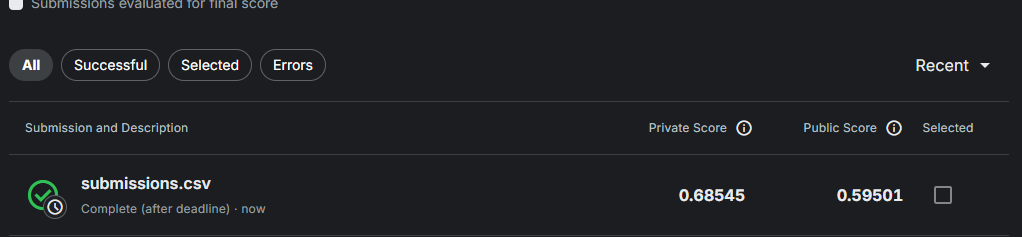

Ну, думаю, недурно. Теперь реализуем voting

In [74]:
from sklearn.base import is_regressor, is_classifier
from scipy.stats import mode
class Voting:
    def fit(self, models, X, y):
        fitted_models = []
        X = np.asarray(X)
        y = np.asarray(y)
        for model in models:
            model_copy = clone(model)
            model_copy.fit(X, y)
            fitted_models.append(model_copy)
        return fitted_models
    def predict(self, fitted_models, X):
        X = np.asarray(X)
        predictions = []
        for fitted_model in fitted_models:
            pred = fitted_model.predict(X)
            predictions.append(pred)
        predictions = np.array(predictions)
        if is_regressor(fitted_models[0]):#наивно полагаю, что все модели в fitted_models будут либо регрессорами, либо классификаторами
            return np.mean(predictions, axis=0)
        if is_classifier(fitted_models[0]):
            return mode(predictions, axis=0).mode

In [75]:
df = pd.read_csv('../datasets/bank.csv', sep=';')
df.info()
X = pd.get_dummies(
    df.drop(columns=['y']),
    drop_first=True
)
y = np.where(df['y'] == 'yes', 1, 0) 
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


In [76]:
voting = Voting()
fitted_models = voting.fit([
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    KNeighborsClassifier(),
    SVC()
], X_train, y_train)
y_pred = voting.predict(fitted_models, X_test)
print(roc_auc_score(y_test, y_pred))

0.5340119284294235


тут уже похуже, но мб потому, что я реализовал hard voting. Софт лень реализовывать, хотя так-то понадобится

In [77]:
df_test = pd.read_csv('../datasets/test.csv', sep=',')
df_test.head()
X_test = pd.get_dummies(df_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

pred = voting.predict(fitted_models, X_test)

In [78]:
df = pd.DataFrame({
    'Id': df_test['Id'],
    'y': pred
})
df.to_csv('submissions_hard_voting.csv', index=False)

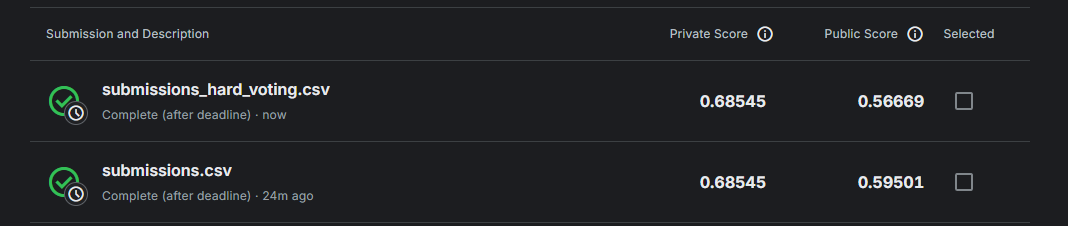

Внезапно, прайват скор одинаковый, это прям неожиданно

Сорева(прошла вообще в 2018): https://www.kaggle.com/competitions/bank-marketing-uci/